In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('alzheimers_disease_data.csv')



In [4]:
df

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,0,0,3.785399,0,0,0,0,1,1,XXXConfid


In [5]:
df.drop(columns=['PatientID', 'DoctorInCharge'], inplace=True)


In [6]:
continuous_cols = [
    'Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity',
    'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP',
    'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
    'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL'
]

binary_cols = [
    'Gender', 'Ethnicity', 'EducationLevel', 'Smoking',
    'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
    'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints',
    'BehavioralProblems', 'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness'
]

target = 'Diagnosis'

In [7]:
X = df.drop(columns=[target])
y = df[target]


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy for logistic regression :", accuracy_score(y_test, y_pred))
print("Precision for logistic regression:", precision_score(y_test, y_pred))
print("Recall for logistic regression :", recall_score(y_test, y_pred))
print("F1 Score for logistic regression:", f1_score(y_test, y_pred))

Accuracy for logistic regression : 0.8302325581395349
Precision for logistic regression: 0.7898550724637681
Recall for logistic regression : 0.7124183006535948
F1 Score for logistic regression: 0.7491408934707904


In [11]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

print("\nAccuracy for decision tree:", accuracy_score(y_test, y_pred_dt))
print("Precision for decision tree:", precision_score(y_test, y_pred_dt))
print("Recall for decision tree  :", recall_score(y_test, y_pred_dt))
print("F1 Score for decision tree:", f1_score(y_test, y_pred_dt))


Accuracy for decision tree: 0.9069767441860465
Precision for decision tree: 0.8896551724137931
Recall for decision tree  : 0.8431372549019608
F1 Score for decision tree: 0.8657718120805369


In [12]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("\nAccuracy for random forest:", accuracy_score(y_test, y_pred_rf))
print("Precision for random forest:", precision_score(y_test, y_pred_rf))
print("Recall  for random forest :", recall_score(y_test, y_pred_rf))
print("F1 Score for random forest:", f1_score(y_test, y_pred_rf))



Accuracy for random forest: 0.9255813953488372
Precision for random forest: 0.9618320610687023
Recall  for random forest : 0.8235294117647058
F1 Score for random forest: 0.8873239436619719


In [13]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("\nAccuracy for random forest:", accuracy_score(y_test, y_pred_rf))
print("Precision for random forest:", precision_score(y_test, y_pred_rf))
print("Recall  for random forest :", recall_score(y_test, y_pred_rf))
print("F1 Score for random forest:", f1_score(y_test, y_pred_rf))


Accuracy for random forest: 0.9255813953488372
Precision for random forest: 0.9618320610687023
Recall  for random forest : 0.8235294117647058
F1 Score for random forest: 0.8873239436619719


In [14]:
from sklearn.svm import SVC

model_svc = SVC(random_state=42,probability=True,class_weight='balanced')

model_svc.fit(X_train_scaled, y_train)

y_pred_svc = model_svc.predict(X_test_scaled)

print("\nAccuracy for svm:", accuracy_score(y_test, y_pred_svc))
print("Precision for svm:", precision_score(y_test, y_pred_svc))
print("Recall for svm :", recall_score(y_test, y_pred_svc))
print("F1 Score for svm:", f1_score(y_test, y_pred_svc))


Accuracy for svm: 0.8325581395348837
Precision for svm: 0.7454545454545455
Recall for svm : 0.803921568627451
F1 Score for svm: 0.7735849056603774


In [15]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print("\nAccuracy for xgboost:", accuracy_score(y_test, y_pred_xgb))
print("Precision for xgboost:", precision_score(y_test, y_pred_xgb))
print("Recall for xgboost:", recall_score(y_test, y_pred_xgb))
print("F1 Score for xgboost:", f1_score(y_test, y_pred_xgb))


Accuracy for xgboost: 0.9511627906976744
Precision for xgboost: 0.9583333333333334
Recall for xgboost: 0.9019607843137255
F1 Score for xgboost: 0.9292929292929293


In [16]:
from sklearn.ensemble import AdaBoostClassifier

model_ada = AdaBoostClassifier(random_state=42)

model_ada.fit(X_train, y_train)

y_pred_ada = model_ada.predict(X_test)

print("\nAccuracy for adaboost:", accuracy_score(y_test, y_pred_ada))
print("Precision for adaboost:", precision_score(y_test, y_pred_ada))
print("Recall for adaboost:", recall_score(y_test, y_pred_ada))
print("F1 Score for adaboost:", f1_score(y_test, y_pred_ada))


Accuracy for adaboost: 0.9162790697674419
Precision for adaboost: 0.9090909090909091
Recall for adaboost: 0.8496732026143791
F1 Score for adaboost: 0.8783783783783784


In [17]:
from lightgbm import LGBMClassifier

model_lgb = LGBMClassifier(random_state=42, verbose=-1)

model_lgb.fit(X_train, y_train)

y_pred_lgb = model_lgb.predict(X_test)

print("\nAccuracy for lightgbm:", accuracy_score(y_test, y_pred_lgb))
print("Precision for lightgbm:", precision_score(y_test, y_pred_lgb))
print("Recall for lightgbm:", recall_score(y_test, y_pred_lgb))
print("F1 Score for lightgbm:", f1_score(y_test, y_pred_lgb))



Accuracy for lightgbm: 0.9558139534883721
Precision for lightgbm: 0.958904109589041
Recall for lightgbm: 0.9150326797385621
F1 Score for lightgbm: 0.9364548494983278


In [18]:
from sklearn.ensemble import BaggingClassifier

model_bag = BaggingClassifier(random_state=42)

model_bag.fit(X_train, y_train)

y_pred_bag = model_bag.predict(X_test)

print("\nAccuracy for bagging:", accuracy_score(y_test, y_pred_bag))
print("Precision for bagging:", precision_score(y_test, y_pred_bag))
print("Recall for bagging:", recall_score(y_test, y_pred_bag))
print("F1 Score for bagging:", f1_score(y_test, y_pred_bag))


Accuracy for bagging: 0.9441860465116279
Precision for bagging: 0.9328859060402684
Recall for bagging: 0.9084967320261438
F1 Score for bagging: 0.9205298013245033


In [19]:
from sklearn.neighbors import KNeighborsClassifier

model_knn=KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

y_pred_knn = model_knn.predict(X_test_scaled)

print("\nAccuracy for knn:", accuracy_score(y_test, y_pred_knn))
print("Precision for knn:", precision_score(y_test, y_pred_knn))
print("Recall for knn:", recall_score(y_test, y_pred_knn))
print("F1 Score for knn:", f1_score(y_test, y_pred_knn))


Accuracy for knn: 0.7186046511627907
Precision for knn: 0.6428571428571429
Recall for knn: 0.47058823529411764
F1 Score for knn: 0.5433962264150943


In [20]:
from sklearn.model_selection import KFold, StratifiedKFold, ShuffleSplit, cross_validate

# 1. K-Fold
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 2. Stratified K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 3. Shuffle Split
ss = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)


folds = {
    "K-Fold": kf,
    "Stratified K-Fold": skf,
    "ShuffleSplit": ss
}

models = {
    "Logistic Regression": model,
    "KNN": model_knn,
    "Decision Tree": model_dt,
    "Random Forest": model_rf,
    "SVC": model_svc,
    "AdaBoost": model_ada,
    "Bagging": model_bag,
    "XGBoost": model_xgb,
    "LightGBM": model_lgb
}


scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

results = []

for fold_name, fold in folds.items():
    for model_name, model in models.items():

        score = cross_validate(
            model, X, y,
            cv=fold,
            scoring=['accuracy', 'precision', 'recall', 'f1']
        )

        results.append([
            fold_name,
            model_name,
            score['test_accuracy'].mean(),
            score['test_precision'].mean(),
            score['test_recall'].mean(),
            score['test_f1'].mean()
        ])

results_df = pd.DataFrame(
    results,
    columns=['Fold', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1']
)

print(results_df.round(4))

c:\Users\sahar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sahar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

                 Fold                Model  Accuracy  Precision  Recall  \
0              K-Fold  Logistic Regression    0.7906     0.7410  0.6303   
1              K-Fold                  KNN    0.5882     0.3845  0.2893   
2              K-Fold        Decision Tree    0.9009     0.8624  0.8592   
3              K-Fold        Random Forest    0.9372     0.9485  0.8721   
4              K-Fold                  SVC    0.6128     0.4665  0.6610   
5              K-Fold             AdaBoost    0.9297     0.9094  0.8940   
6              K-Fold              Bagging    0.9414     0.9388  0.8954   
7              K-Fold              XGBoost    0.9488     0.9444  0.9107   
8              K-Fold             LightGBM    0.9516     0.9447  0.9185   
9   Stratified K-Fold  Logistic Regression    0.7813     0.7256  0.6224   
10  Stratified K-Fold                  KNN    0.5942     0.3971  0.2987   
11  Stratified K-Fold        Decision Tree    0.8939     0.8483  0.8553   
12  Stratified K-Fold    

c:\Users\sahar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


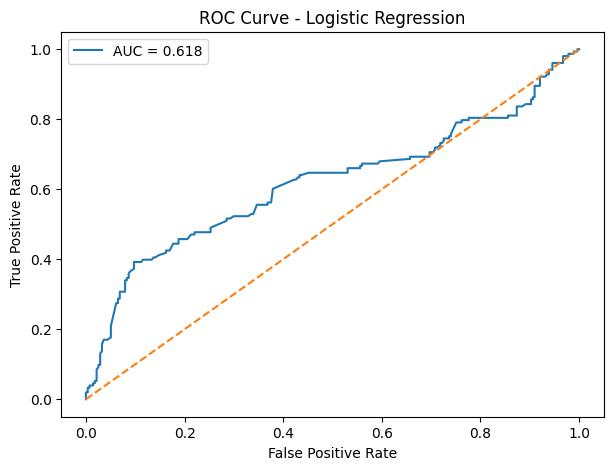

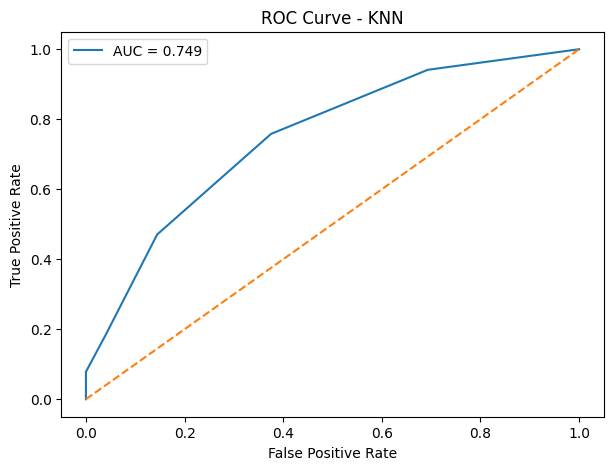

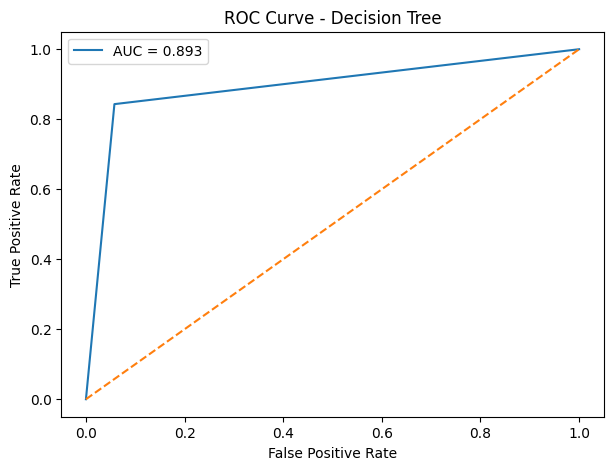

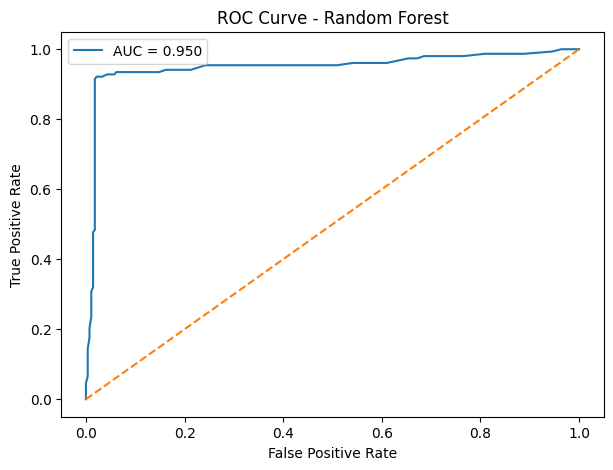

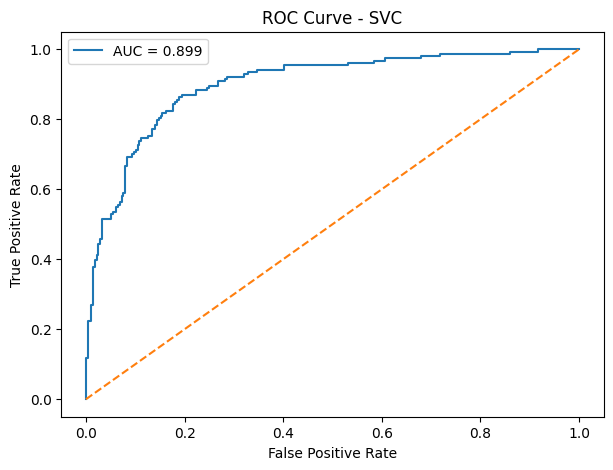

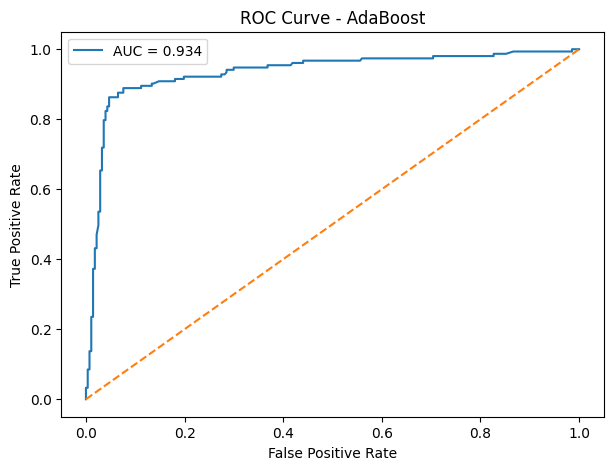

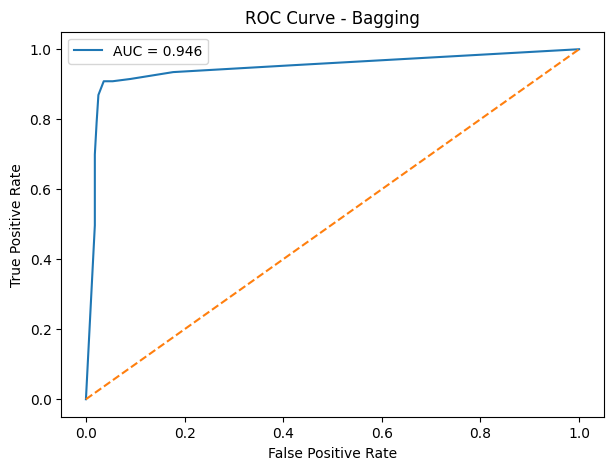

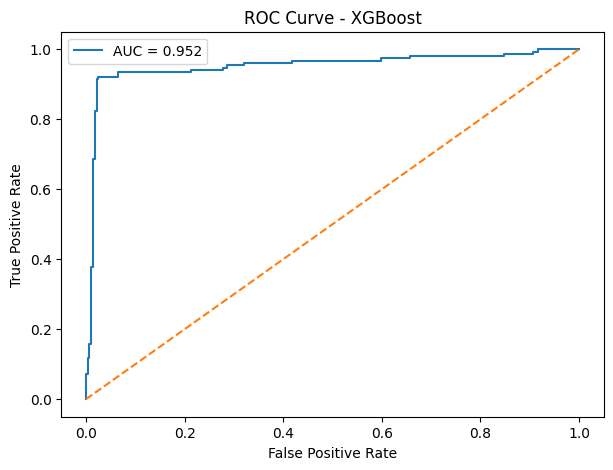

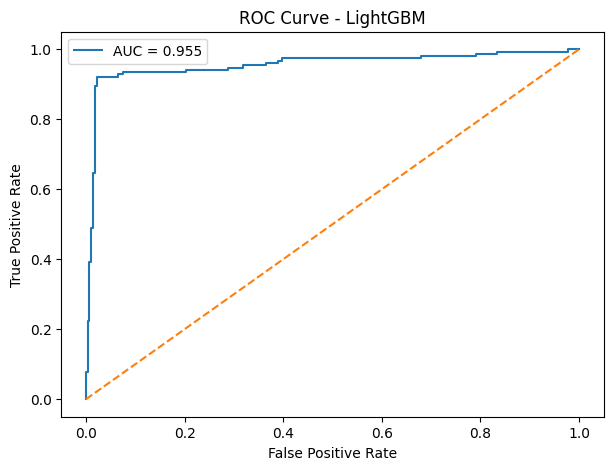

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

models_data = {
    "Logistic Regression": (model, X_test_scaled),
    "KNN": (model_knn, X_test_scaled),
    "Decision Tree": (model_dt, X_test),
    "Random Forest": (model_rf, X_test),
    "SVC": (model_svc, X_test_scaled),
    "AdaBoost": (model_ada, X_test),
    "Bagging": (model_bag, X_test),
    "XGBoost": (model_xgb, X_test),
    "LightGBM": (model_lgb, X_test)
}

for name, (model, X_data) in models_data.items():

    y_prob = model.predict_proba(X_data)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.figure(figsize=(7, 5))

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")

    plt.legend()
    plt.show()

c:\Users\sahar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\sahar\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

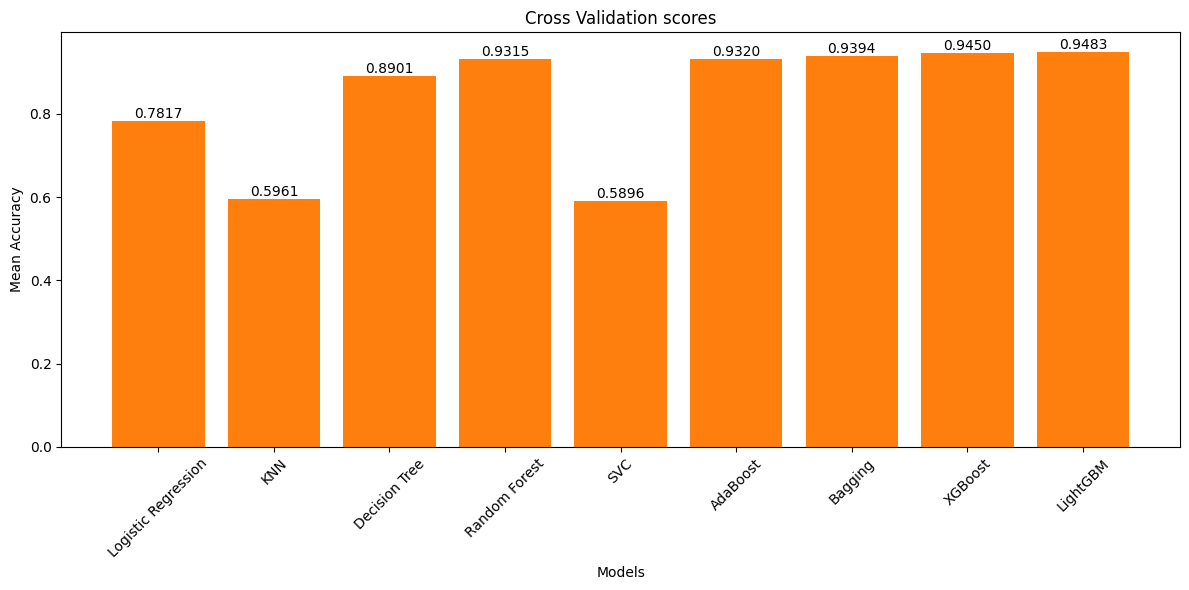

<Figure size 640x480 with 0 Axes>

In [22]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

results = {}

for name, model in models.items():

    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

    results[name] = scores.mean()

# Bar chart
plt.figure(figsize=(12, 6))

bars = plt.bar(results.keys(), results.values())

plt.title("Cross Validation scores")
plt.xlabel("Models")
plt.ylabel("Mean Accuracy")
plt.xticks(rotation=45)

bars = plt.bar(results.keys(), results.values())

plt.bar_label(bars, fmt='%.4f')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

In [23]:
print('''We trained 9 models and compared them using 
4 evaluation methods:

1. f1,roc_auc,accuracy,precision,recall
2. KFold Cross Validation
3. Stratified KFold
4. ShuffleSplit

Models Trained:
1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. SVC
6. AdaBoost
7. Bagging
8. XGBoost
9. LightGBM

Strong Models:

LightGBM  : Consistent 95%+ across all methods
XGBoost   : Consistent 95%+ across all methods
Bagging   : Consistent 94%+ across all methods

These 3 were selected for Hyperparameter 
Tuning using GridSearchCV with scoring = roc_auc and recall''')

We trained 9 models and compared them using 
4 evaluation methods:

1. f1,roc_auc,accuracy,precision,recall
2. KFold Cross Validation
3. Stratified KFold
4. ShuffleSplit

Models Trained:
1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. SVC
6. AdaBoost
7. Bagging
8. XGBoost
9. LightGBM

Strong Models:

LightGBM  : Consistent 95%+ across all methods
XGBoost   : Consistent 95%+ across all methods
Bagging   : Consistent 94%+ across all methods

These 3 were selected for Hyperparameter 
Tuning using GridSearchCV with scoring = roc_auc and recall


In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
lgbm_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
lgbm = GridSearchCV(model_lgb, lgbm_params, cv=5, scoring='roc_auc')
lgbm.fit(X_train, y_train)
print("Best LightGBM Params for auc score:", lgbm.best_params_)
print("Best LightGBM AUC Score:", lgbm.best_score_)


lgbm_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
lgbm = GridSearchCV(model_lgb, lgbm_params, cv=5, scoring='recall')
lgbm.fit(X_train, y_train)
print("Best LightGBM Params for recall:", lgbm.best_params_)
print("Best LightGBM Recall:", lgbm.best_score_)

Best LightGBM Params for auc score: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 300}
Best LightGBM AUC Score: 0.952647167974335
Best LightGBM Params for recall: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300}
Best LightGBM Recall: 0.9126270153095787


In [26]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}
xgb = GridSearchCV(model_xgb, xgb_params, cv=5, scoring='roc_auc')
xgb.fit(X_train, y_train)
print("Best XGBoost Params for auc score:", xgb.best_params_)
print("Best XGBoost AUC Score:", xgb.best_score_)

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7], 
    'learning_rate': [0.01, 0.05, 0.1]
}
xgb = GridSearchCV(model_xgb, xgb_params, cv=5, scoring='recall')
xgb.fit(X_train, y_train)
print("Best XGBoost Params for recall:", xgb.best_params_)
print("Best XGBoost Recall:", xgb.best_score_)

Best XGBoost Params for auc score: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best XGBoost AUC Score: 0.9535393776680792
Best XGBoost Params for recall: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200}
Best XGBoost Recall: 0.9175992412952174


In [27]:
bag_params = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

bag_grid = GridSearchCV(model_bag, bag_params, cv=5, scoring='roc_auc')
bag_grid.fit(X_train, y_train)

print("Best Params for bagging AUC score:", bag_grid.best_params_)
print("Best Score for bagging AUC score:", bag_grid.best_score_)

bag_params = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0]
}

bag_grid = GridSearchCV(model_bag, bag_params, cv=5, scoring='recall')
bag_grid.fit(X_train, y_train)

print("Best Params for bagging Recall:", bag_grid.best_params_)
print("Best Score for bagging Recall:", bag_grid.best_score_)

Best Params for bagging AUC score: {'max_features': 1.0, 'max_samples': 0.5, 'n_estimators': 100}
Best Score for bagging AUC score: 0.9526719334539134
Best Params for bagging Recall: {'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 100}
Best Score for bagging Recall: 0.9044031973987264


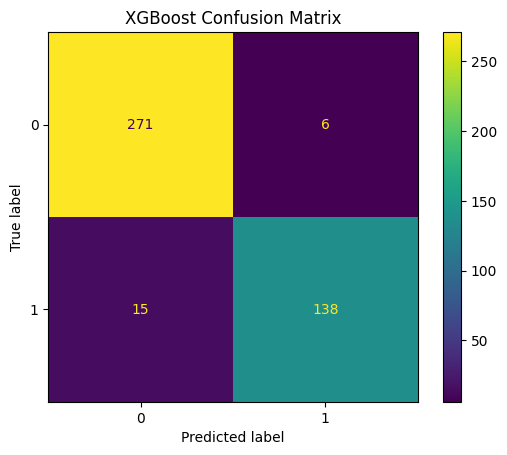

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, model_xgb.predict(X_test))
ConfusionMatrixDisplay(cm).plot()
plt.title('XGBoost Confusion Matrix')
plt.show()

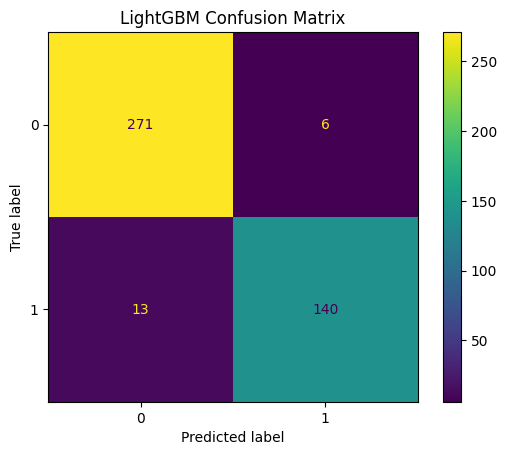

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, model_lgb.predict(X_test))
ConfusionMatrixDisplay(cm).plot()
plt.title('LightGBM Confusion Matrix')
plt.show()

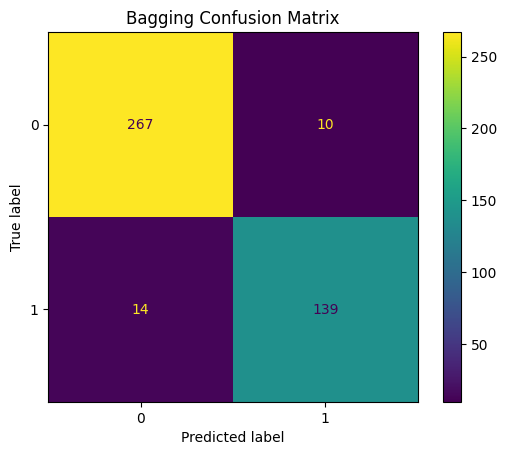

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, model_bag.predict(X_test))
ConfusionMatrixDisplay(cm).plot()
plt.title('Bagging Confusion Matrix')
plt.show()

In [31]:
print('''In this project we built a Machine Learning model 
to detect Alzheimer's Disease using patient data.

Dataset:
2149 patients, 33 features
Synthetically generated — zero nulls, zero outliers

Model Building:
9 models were trained and evaluated
KNN and SVC completely failed
Logistic Regression showed overfitting
Top 3 models selected for hyperparameter tuning —
LightGBM, XGBoost and Bagging

Final Model:
LightGBM is selected as our final model

Reasons:
Accuracy  : 95.58%
AUC Score : 0.9547
Recall    : 91.50%
Correctly identified 140 Alzheimer's patients
Missed only 13 patients — lowest false negatives

In medical diagnosis missing a sick patient 
is the most dangerous outcome.
LightGBM minimizes this risk better than 
any other model in our comparison.
''')

In this project we built a Machine Learning model 
to detect Alzheimer's Disease using patient data.

Dataset:
2149 patients, 33 features
Synthetically generated — zero nulls, zero outliers

Model Building:
9 models were trained and evaluated
KNN and SVC completely failed
Logistic Regression showed overfitting
Top 3 models selected for hyperparameter tuning —
LightGBM, XGBoost and Bagging

Final Model:
LightGBM is selected as our final model

Reasons:
Accuracy  : 95.58%
AUC Score : 0.9547
Recall    : 91.50%
Correctly identified 140 Alzheimer's patients
Missed only 13 patients — lowest false negatives

In medical diagnosis missing a sick patient 
is the most dangerous outcome.
LightGBM minimizes this risk better than 
any other model in our comparison.



In [32]:
print('''Although XGBoost showed better scores after hyperparameter tuning, LightGBM was selected as final 
model because it correctly identified 2 more Alzheimer's 
patients and missed 2 fewer patients in real test data — in medical diagnosis patient safety is top priority
and it shows best scores in all the metrics unlike XGBoost''')

Although XGBoost showed better scores after hyperparameter tuning, LightGBM was selected as final 
model because it correctly identified 2 more Alzheimer's 
patients and missed 2 fewer patients in real test data — in medical diagnosis patient safety is top priority
and it shows best scores in all the metrics unlike XGBoost


In [34]:
import pickle

pickle.dump(model_lgb, open('alzheimer_model.pkl', 'wb'))

median_values = df.drop('Diagnosis', axis=1).median().to_dict()
pickle.dump(median_values, open('median_values.pkl', 'wb'))

print("Model saved!")
print("Median values saved!")

Model saved!
Median values saved!
